# [Voting - classification](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.VotingClassifier.html#sklearn.ensemble.VotingClassifier)

In [1]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier
from sklearn import datasets
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
import os
import random
import numpy as np

def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
#    torch.manual_seed(seed)
#    torch.cuda.manual_seed(seed)
#    torch.backends.cudnn.deterministic = True
#    torch.backends.cudnn.benchmark = False

seed_everything(42)

In [3]:
data = datasets.load_iris()

In [4]:
X_data = data.data
y_data = data.target

In [5]:
import numpy as np
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2) # train과 test를 8:2로 분할

In [6]:
clf1 = DecisionTreeClassifier()
clf2 = RandomForestClassifier(n_estimators=50, random_state=1)
clf3 = GaussianNB()

model = VotingClassifier(estimators=[('dt', clf1), ('rf', clf2), ('gnb', clf3)], voting='hard')

In [7]:
model.fit(X_train, y_train)

,estimators,"[('dt', ...), ('rf', ...), ...]"
,voting,'hard'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1


In [8]:
y = model.predict(X_train)

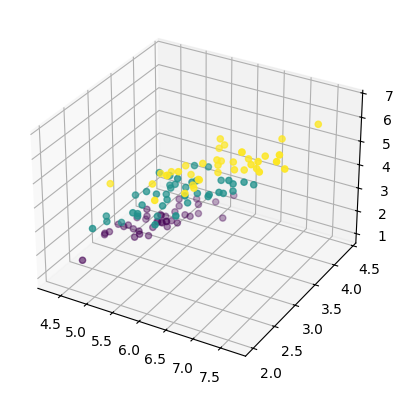

In [9]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d, Axes3D 

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_train[:,0], X_train[:,1], X_train[:,2], c = y_train)
plt.show()

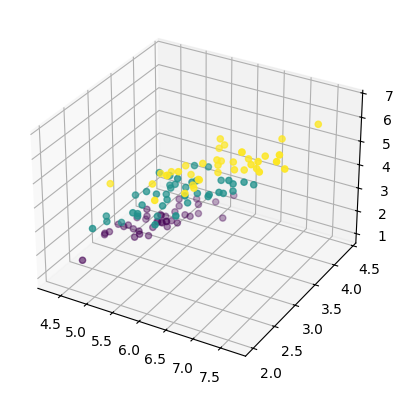

In [10]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d, Axes3D 

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_train[:,0], X_train[:,1], X_train[:,2], c = y)
plt.show()

In [11]:
print(model.score(X_train, y_train))

1.0


In [12]:
clf1 = DecisionTreeClassifier()
clf2 = RandomForestClassifier(n_estimators=50, random_state=1)
clf3 = GaussianNB()

model = VotingClassifier(estimators=[('ct', clf1), ('rf', clf2), ('gnb', clf3)], voting='soft')

In [13]:
model.fit(X_train, y_train)

,estimators,"[('ct', ...), ('rf', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1


In [14]:
print(model.score(X_train, y_train))

1.0


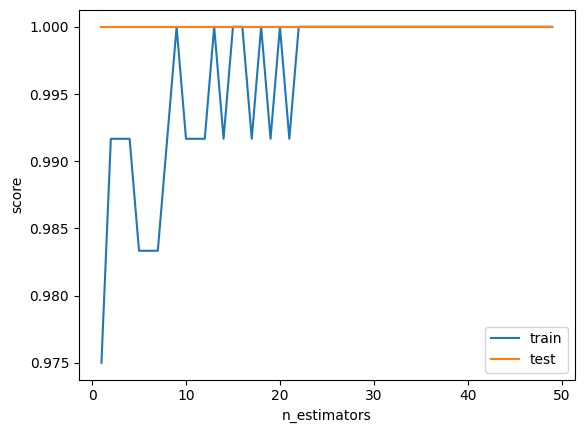

In [15]:
train_score = []
test_score = []
n_range = range(1, 50)

for n in n_range:
    clf1 = DecisionTreeClassifier()
    clf2 = RandomForestClassifier(n_estimators=n, random_state=1)
    clf3 = GaussianNB()

    model = VotingClassifier(estimators=[('dt', clf1), ('rf', clf2), ('gnb', clf3)], voting='soft')
    model.fit(X_train, y_train)
    train_score.append(model.score(X_train, y_train))
    test_score.append(model.score(X_test, y_test))

plt.figure()
plt.plot(n_range, train_score, label='train')
plt.plot(n_range, test_score, label='test')
plt.legend()
plt.xlabel('n_estimators')
plt.ylabel('score')
plt.show()